In [ ]:
# --------------------------------
# Imports & Path Setup
# --------------------------------

%reload_ext autoreload
%autoreload 2

import os
print(os.getcwd())

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import torch
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim

from src.utils.trainer import Trainer
from src.utils.logger import Logger

/hpc/home/efavale/deep-image-restoration


: 

In [9]:
# --------------------------------
# Trainer Setup
# --------------------------------

LOG_DIR = Path("logs")

RESIZED_DIR = Path("data/resized")
COMPRESSED_DIR = Path("data/compressed")
CHECKPOINTS_DIR = Path("checkpoints")

logger = Logger(
    dir=LOG_DIR,
    description="ConvAutoencoder-SkipConnections-BothCompressions"
)

# ConvAutoencoder
trainer = Trainer(
    input_dir=RESIZED_DIR,
    compressed_dir=COMPRESSED_DIR,
    checkpoints_dir=CHECKPOINTS_DIR,
    checkpoint_name="best_model_autoencoder",
    logger=logger,
    base_channels=32,
    batch_size=4,
    learning_rate=1e-3,
    weight_decay=1e-4,
)

trainer.load_dataset()

: 

: 

In [ ]:
# --------------------------------
# Training
# --------------------------------

history = trainer.train(num_epochs=100)

/hpc/home/efavale/miniconda3/envs/deep-image-restoration/lib/python3.12/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch   1/100  |  Train Loss: 0.253131  |  Val Loss:   0.240295
Epoch  10/100  |  Train Loss: 0.128815  |  Val Loss:   0.142019
Epoch  20/100  |  Train Loss: 0.118618  |  Val Loss:   0.132207
Epoch  30/100  |  Train Loss: 0.109962  |  Val Loss:   0.129033
Epoch  40/100  |  Train Loss: 0.100787  |  Val Loss:   0.127700
Epoch  50/100  |  Train Loss: 0.091232  |  Val Loss:   0.127318
Epoch  60/100  |  Train Loss: 0.083227  |  Val Loss:   0.129046
Epoch  70/100  |  Train Loss: 0.072293  |  Val Loss:   0.130678
Epoch  80/100  |  Train Loss: 0.059215  |  Val Loss:   0.134992
Epoch  90/100  |  Train Loss: 0.051146  |  Val Loss:   0.135973
Epoch 100/100  |  Train Loss: 0.051245  |  Val Loss:   0.136125

Training complete — Best val loss: 0.126039 (epoch 37)
Checkpoint saved: checkpoints/best_model_autoencoder_20260310_104214.pth
[Logger] Log saved to: logs/20260310_104214_ConvAutoencoder-SkipConnections-BothCompressions.log


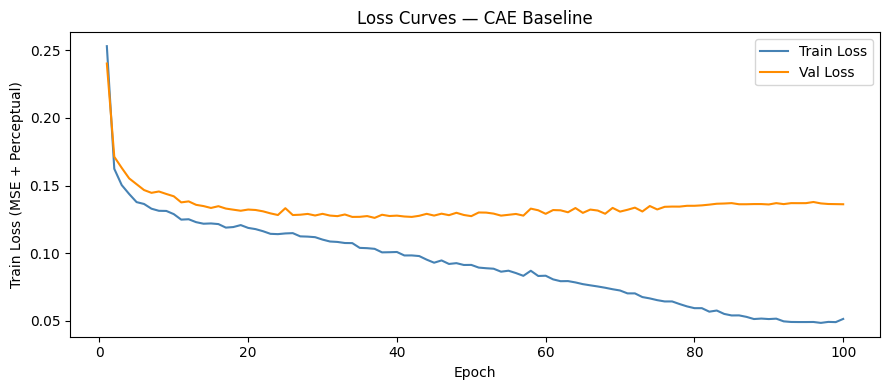

In [ ]:
# --------------------------------
# Loss Curves
# --------------------------------

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
plt.plot(epochs, history["val_loss"], label="Val Loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Train Loss (MSE + Perceptual)")
plt.title("Loss Curves — CAE Baseline")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------
# Load Best Checkpoint
# --------------------------------

trainer.model.load_state_dict(
    torch.load(
        Path("checkpoints/best_model_autoencoder.pth"), map_location=trainer.device
    )
)
trainer.model.eval()
print(" Best model loaded")

 Best model loaded


In [ ]:
# --------------------------------
# Baseline PSNR — Compressed vs Original
# --------------------------------

psnr_baseline, ssim_baseline = [], []

for compressed, original in trainer.test_loader:
    for comp_t, orig_t in zip(compressed.numpy(), original.numpy()):
        comp_np = np.transpose(comp_t, (1, 2, 0))
        orig_np = np.transpose(orig_t, (1, 2, 0))
        psnr_baseline.append(calc_psnr(orig_np, comp_np, data_range=1.0))
        ssim_baseline.append(
            calc_ssim(orig_np, comp_np, data_range=1.0, channel_axis=2)
        )

psnr_base = np.mean(psnr_baseline)
ssim_base = np.mean(ssim_baseline)
print(f"Baseline  —  PSNR: {psnr_base:.2f} dB  |  SSIM: {ssim_base:.4f}")

Baseline  —  PSNR: 25.51 dB  |  SSIM: 0.8093


In [ ]:
# --------------------------------
# PSNR / SSIM — Restored vs Original
# --------------------------------

psnr_list, ssim_list = [], []

with torch.no_grad():
    for compressed, original in trainer.test_loader:
        compressed = compressed.to(trainer.device)
        original = original.to(trainer.device)
        recon, _ = trainer.model(compressed)

        for out_t, orig_t in zip(recon.cpu().numpy(), original.cpu().numpy()):
            out_np = np.transpose(out_t, (1, 2, 0))
            orig_np = np.transpose(orig_t, (1, 2, 0))
            psnr_list.append(calc_psnr(orig_np, out_np, data_range=1.0))
            ssim_list.append(calc_ssim(orig_np, out_np, data_range=1.0, channel_axis=2))

psnr_mean = np.mean(psnr_list)
ssim_mean = np.mean(ssim_list)

print(f"{'─' * 50}")
print(f"  PSNR baseline (compressed) : {psnr_base:.2f} dB")
print(
    f"  PSNR restored              : {psnr_mean:.2f} dB  ({psnr_mean - psnr_base:+.2f})"
)
print(f"  SSIM baseline (compressed) : {ssim_base:.4f}")
print(f"  SSIM restored              : {ssim_mean:.4f}  ({ssim_mean - ssim_base:+.4f})")
print(f"{'─' * 50}")

──────────────────────────────────────────────────
  PSNR baseline (compressed) : 25.51 dB
  PSNR restored              : 24.30 dB  (-1.21)
  SSIM baseline (compressed) : 0.8093
  SSIM restored              : 0.7258  (-0.0835)
──────────────────────────────────────────────────
